# Modeling

Training CNN architectures on the augmented OCT volume dataset.

**Key design choices:**
- Train on augmented data (6x original) with normalization (÷255) and shuffling
- Evaluate on the original (non-augmented) test set for fair comparison with Part 1

## Imports

In [1]:
import sys
sys.path.append('..')

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from octcv.mdl_lib import yX_split, XVolSet, ModelEvaluator, train_model
from octcv.mdl_lib.architectures import buildSequential, buildResNet, buildAttnNN
from octcv.mdl_lib.callbacks import LivePlot
from octcv.system_monitoring import startMemoryMonitor

In [2]:
startMemoryMonitor()

## Load & Split Data

In [3]:
# Load augmented metadata (6660 entries: 1110 original + 5×1110 augmented)
aug_df = pd.read_csv('../datasrc/volumeOCT-AUGMENTED_metadata.csv')
print(f"Augmented dataset: {len(aug_df)} entries")
print(f"Augmentations: {aug_df['augmentation'].unique()}")

# Load original train/test splits from Part 1
v_train = pd.read_csv('../p5_Modeling/volumes_train.csv')
v_test = pd.read_csv('../p5_Modeling/volumes_TEST.csv')
print(f"\nOriginal split: {len(v_train)} train / {len(v_test)} test")

Augmented dataset: 6660 entries
Augmentations: ['original' 'dark' 'bright' 'noise' 'lpf' 'fan']

Original split: 888 train / 222 test


In [4]:
# Build augmented TRAINING set (all 6 versions of each training volume)
nonpath_columns = ['dx_class', 'glaucoma', 'PIN', 'laterality', 'left_eye', 'set']
augmentations = aug_df['augmentation'].unique()

augpiv = aug_df.pivot(
    index=nonpath_columns, columns='augmentation', values='display_volume'
).rename_axis(None, axis=1).reset_index()

augpiv_train = pd.merge(
    v_train, augpiv[list(augmentations)],
    left_on='display_volume', right_on='original', how='left'
).drop(columns='display_volume')

augTRAIN = pd.melt(
    augpiv_train, id_vars=nonpath_columns,
    var_name='augmentation', value_vars=augmentations,
    value_name='display_volume'
)

# VALIDATION: use augmented versions for richer validation signal during training
# EVALUATION: use ONLY original test volumes (fair comparison with Part 1)
v_valid, v_eval = train_test_split(v_test, test_size=0.5, random_state=42)

print(f"Augmented train: {len(augTRAIN)}")
print(f"Validation (original): {len(v_valid)}")
print(f"Evaluation (original): {len(v_eval)}")

Augmented train: 5328
Validation (original): 111
Evaluation (original): 111


## Create tf.data.Dataset Pipelines

Volumes are loaded lazily in batches, normalized to [0,1], and shuffled.

In [5]:
BATCH_SIZE = 4

# Training: augmented, shuffled, normalized (raw uint8 / 255)
_, ay_train, aX_train = yX_split(augTRAIN, display_filepath_columns='display_volume',
                                  default_load_normalized=False)

# Validation: original volumes, same normalization as training
_, vy_valid, vX_valid = yX_split(v_valid, display_filepath_columns='display_volume',
                                  default_load_normalized=False)

# Evaluation: original volumes, same normalization
_, vy_eval, vX_eval = yX_split(v_eval, display_filepath_columns='display_volume',
                                default_load_normalized=False)

print(f"Input shape: {aX_train.input_shape}")
print(f"Train batches/epoch: ~{len(aX_train) // BATCH_SIZE}")
print(f"Validation samples: {len(vX_valid)}")
print(f"Evaluation samples: {len(vX_eval)}")


Input shape: (64, 128, 64, 1)
Train batches/epoch: ~1332
Validation samples: 111
Evaluation samples: 111


## Model 1: Sequential CNN

In [6]:
model_seq = buildSequential()
model_seq.summary()

I0000 00:00:1780631916.009707 2477032 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9888 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Ti, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "original_sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ BLOCK1_Conv3D (Conv3D)          │ (None, 32, 64, 32, 32) │        11,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BLOCK1_BatchNorm                │ (None, 32, 64, 32, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BLOCK1_ReLU (ReLU)              │ (None, 32, 64, 32, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BLOCK2_Conv3D (Conv3D)          │ (None, 32, 64, 32, 32) │       128,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BLOCK2_BatchNorm                │ (None, 32, 64, 32, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BLOCK2_ReLU (ReLU)              │ (None, 32, 64, 32, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BLOCK3_Conv3D (Conv3D)          │ (None, 32, 64, 32, 32) │       128,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BLOCK3_BatchNorm                │ (None, 32, 64, 32, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BLOCK3_ReLU (ReLU)              │ (None, 32, 64, 32, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BLOCK4_Conv3D (Conv3D)          │ (None, 32, 64, 32, 32) │        27,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BLOCK4_BatchNorm                │ (None, 32, 64, 32, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BLOCK4_ReLU (ReLU)              │ (None, 32, 64, 32, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BLOCK5_Conv3D (Conv3D)          │ (None, 32, 64, 32, 32) │        27,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BLOCK5_BatchNorm                │ (None, 32, 64, 32, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BLOCK5_ReLU (ReLU)              │ (None, 32, 64, 32, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GlobalAveragePooling3D          │ (None, 32)             │             0 │
│ (GlobalAveragePooling3D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 323,105 (1.23 MB)

 Trainable params: 322,785 (1.23 MB)

 Non-trainable params: 320 (1.25 KB)

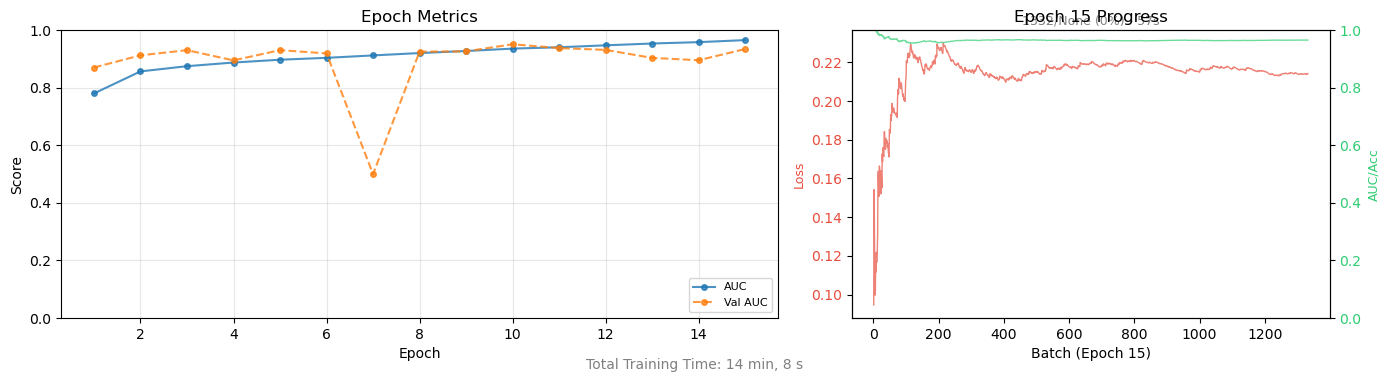

In [7]:
train_ds = aX_train.to_tf_dataset(ay_train, batch_size=BATCH_SIZE, shuffle=True)
valid_ds = vX_valid.to_tf_dataset(vy_valid, batch_size=BATCH_SIZE, shuffle=False)

history_seq = train_model(
    model_seq, train_ds, valid_ds,
    epochs=50, patience=5, learning_rate=1e-4,
    live_plot=True, metrics_to_plot=['auc', 'val_auc']
)

/home/etudie/PROJECTS/OCTCV/PART_2/../octcv/mdl_lib/__init__.py:679: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


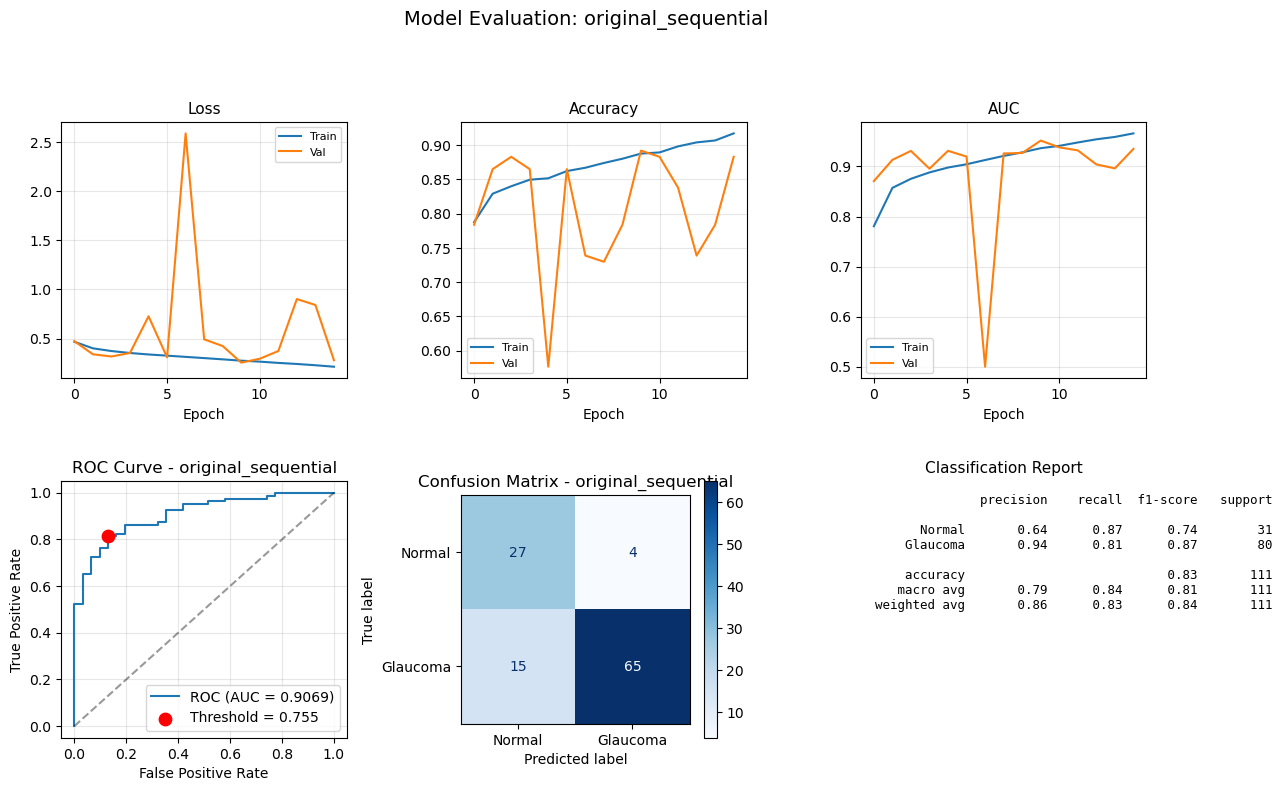


AUC: 0.9069 | Threshold: 0.7555


In [8]:
eval_ds = vX_eval.to_tf_dataset(vy_eval, batch_size=BATCH_SIZE, shuffle=False)
evaluator_seq = ModelEvaluator(model_seq, history_seq, eval_ds)
evaluator_seq.summary()

## Model 2: ResNet-Like

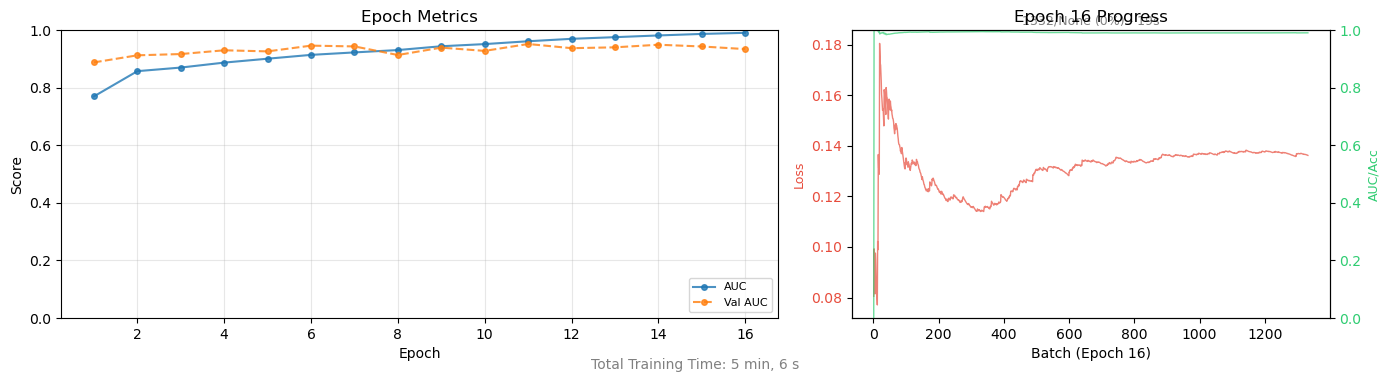

In [9]:
model_res = buildResNet()

train_ds = aX_train.to_tf_dataset(ay_train, batch_size=BATCH_SIZE, shuffle=True)
valid_ds = vX_valid.to_tf_dataset(vy_valid, batch_size=BATCH_SIZE, shuffle=False)

history_res = train_model(
    model_res, train_ds, valid_ds,
    epochs=50, patience=5, learning_rate=1e-4,
    live_plot=True
)

/home/etudie/PROJECTS/OCTCV/PART_2/../octcv/mdl_lib/__init__.py:679: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


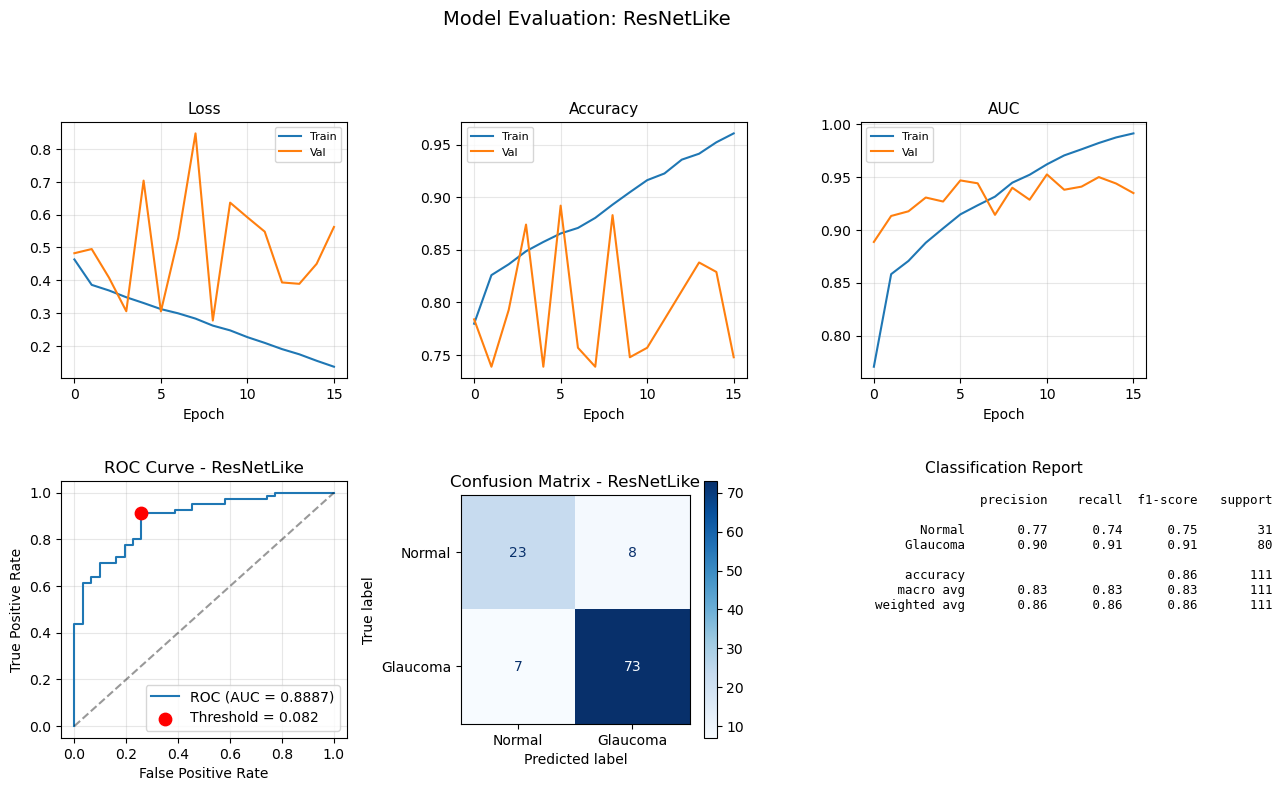


AUC: 0.8887 | Threshold: 0.0818


In [10]:
eval_ds = vX_eval.to_tf_dataset(vy_eval, batch_size=BATCH_SIZE, shuffle=False)
evaluator_res = ModelEvaluator(model_res, history_res, eval_ds)
evaluator_res.summary()

## Model 3: Attention Network

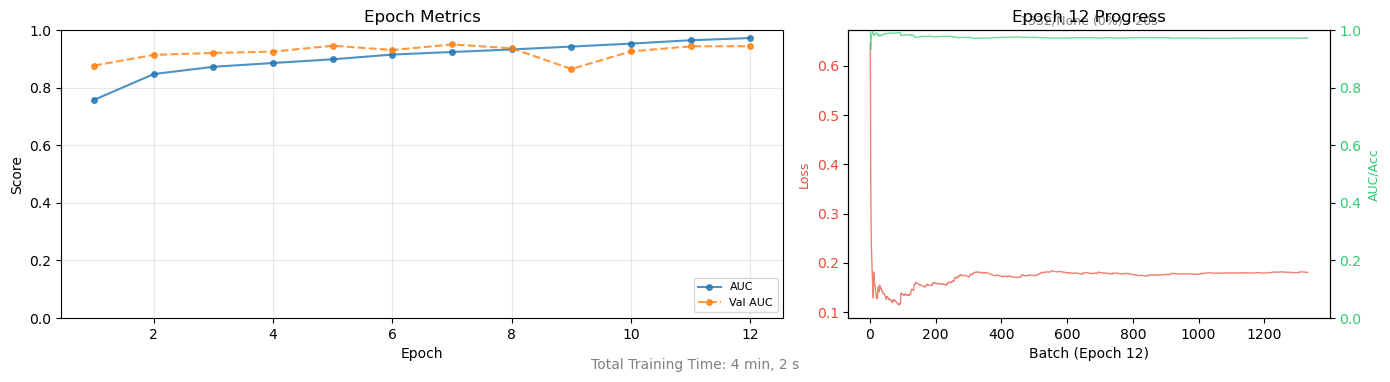

In [11]:
model_attn = buildAttnNN()

train_ds = aX_train.to_tf_dataset(ay_train, batch_size=BATCH_SIZE, shuffle=True)
valid_ds = vX_valid.to_tf_dataset(vy_valid, batch_size=BATCH_SIZE, shuffle=False)

history_attn = train_model(
    model_attn, train_ds, valid_ds,
    epochs=50, patience=5, learning_rate=1e-4,
    live_plot=True
)

/home/etudie/PROJECTS/OCTCV/PART_2/../octcv/mdl_lib/__init__.py:679: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


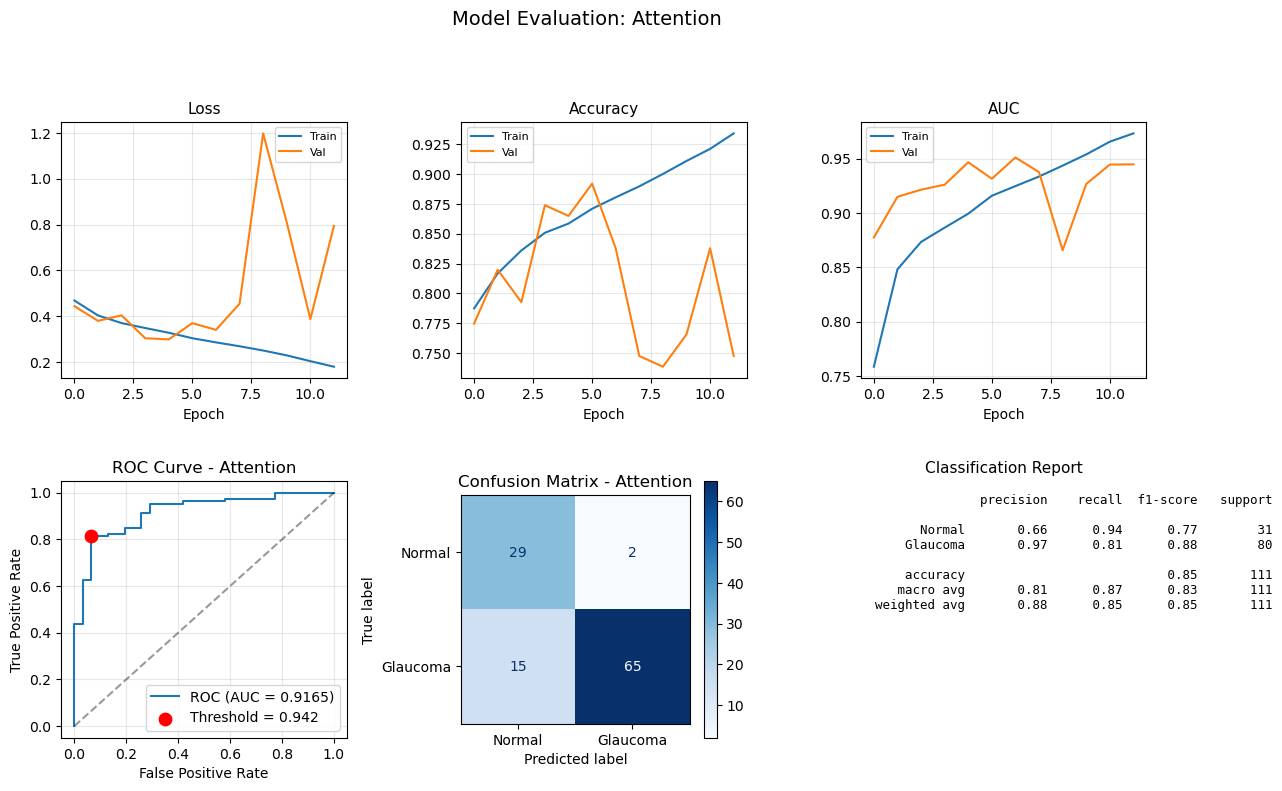


AUC: 0.9165 | Threshold: 0.9420


In [12]:
eval_ds = vX_eval.to_tf_dataset(vy_eval, batch_size=BATCH_SIZE, shuffle=False)
evaluator_attn = ModelEvaluator(model_attn, history_attn, eval_ds)
evaluator_attn.summary()

## Model Comparison

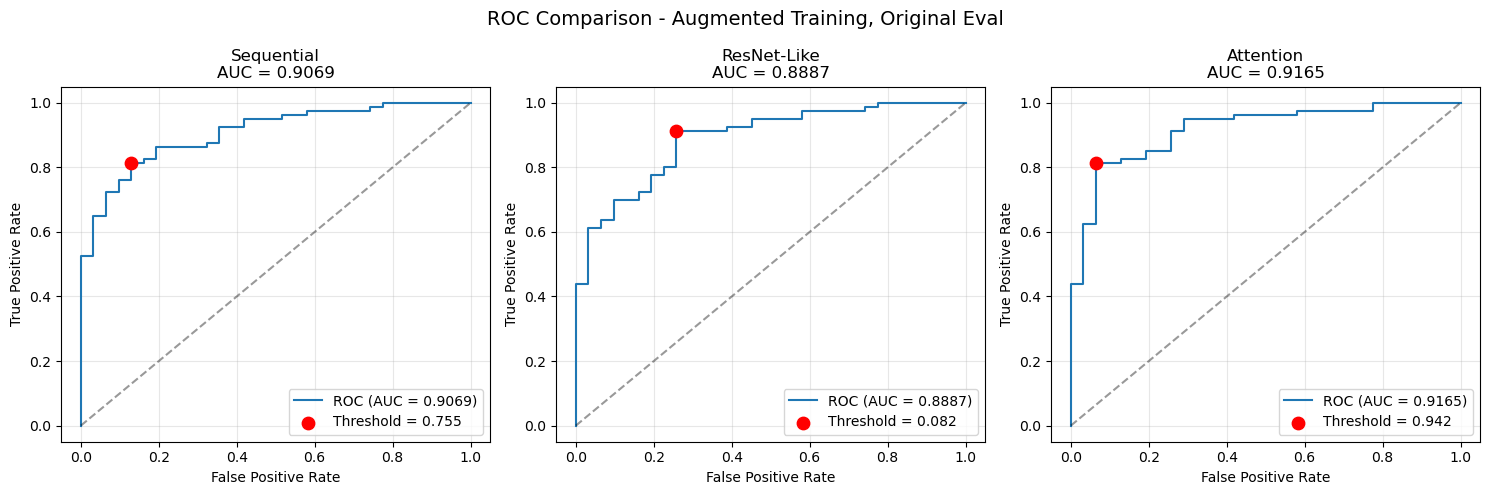


Model           AUC      Threshold   
-----------------------------------
Sequential      0.9069   0.7555
ResNet-Like     0.8887   0.0818
Attention       0.9165   0.9420

Part 1 baselines: Sequential ~0.88, ResNet ~0.94, Attention ~0.93


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
models_data = [
    (evaluator_seq, 'Sequential'),
    (evaluator_res, 'ResNet-Like'),
    (evaluator_attn, 'Attention'),
]

for ax, (ev, name) in zip(axes, models_data):
    ev.plot_roc(ax=ax)
    ax.set_title(f'{name}\nAUC = {ev.roc_auc():.4f}')

plt.suptitle('ROC Comparison - Augmented Training, Original Eval', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\n{'Model':<15} {'AUC':<8} {'Threshold':<12}")
print('-' * 35)
for ev, name in models_data:
    print(f"{name:<15} {ev.roc_auc():.4f}   {ev.threshold:.4f}")

print(f"\nPart 1 baselines: Sequential ~0.88, ResNet ~0.94, Attention ~0.93")

## Part 1 vs Part 2 Comparison

Comparing model performance when trained on the original 888 volumes (Part 1) vs the 6x augmented dataset of 5328 volumes (Part 2). Both evaluated on the same 111 original test volumes.

In [ ]:
# Part 1 vs Part 2 detailed comparison
# Part 1 results from p5_Modeling/modeling.ipynb (trained on 888 original volumes)
part1_results = {
    'Sequential': {'auc': 0.88, 'epochs': 11, 'dataset': 'Original (888)'},
    'ResNet-Like': {'auc': 0.94, 'epochs': 15, 'dataset': 'Original (888)'},
    'Attention': {'auc': 0.93, 'epochs': 18, 'dataset': 'Original (888)'},
}

# Part 2 results (trained on 5328 augmented volumes)
part2_results = {
    'Sequential': {'auc': evaluator_seq.roc_auc(), 'epochs': len(history_seq.history['loss']), 'dataset': 'Augmented (5328)'},
    'ResNet-Like': {'auc': evaluator_res.roc_auc(), 'epochs': len(history_res.history['loss']), 'dataset': 'Augmented (5328)'},
    'Attention': {'auc': evaluator_attn.roc_auc(), 'epochs': len(history_attn.history['loss']), 'dataset': 'Augmented (5328)'},
}

# Build comparison DataFrame
rows = []
for model_name in ['Sequential', 'ResNet-Like', 'Attention']:
    p1 = part1_results[model_name]
    p2 = part2_results[model_name]
    delta = p2['auc'] - p1['auc']
    rows.append({
        'Architecture': model_name,
        'Part 1 AUC': f"{p1['auc']:.4f}",
        'Part 1 Epochs': p1['epochs'],
        'Part 2 AUC': f"{p2['auc']:.4f}",
        'Part 2 Epochs': p2['epochs'],
        'Delta AUC': f"{delta:+.4f}",
        'Improved?': '✓' if delta > 0 else '✗'
    })

comparison_df = pd.DataFrame(rows)
print("="*70)
print("PART 1 vs PART 2 — Model Performance Comparison")
print("="*70)
print(f"Part 1: Trained on 888 original volumes (normalized_array)")
print(f"Part 2: Trained on 5328 augmented volumes (display_volume / 255)")
print(f"Eval:   Same 111 original test volumes in both cases")
print("-"*70)
print(comparison_df.to_string(index=False))
print("="*70)


In [ ]:
# Visual comparison: grouped bar chart
fig, ax = plt.subplots(figsize=(8, 5))

models = ['Sequential', 'ResNet-Like', 'Attention']
p1_aucs = [part1_results[m]['auc'] for m in models]
p2_aucs = [part2_results[m]['auc'] for m in models]

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, p1_aucs, width, label='Part 1 (Original 888)', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, p2_aucs, width, label='Part 2 (Augmented 5328)', color='#e74c3c', alpha=0.8)

ax.set_ylabel('AUC', fontsize=12)
ax.set_title('Model Performance: Original vs Augmented Training', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0.6, 1.0)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


## Hyperparameter Tuning

Grid search over learning rates using the best-performing architecture from above.

In [14]:
learning_rates = [5e-5, 1e-4, 3e-4, 5e-4]
results = []

for lr in learning_rates:
    print(f"\nLR = {lr}")
    model = buildSequential(model_name=f'seq_lr{lr}')

    train_ds = aX_train.to_tf_dataset(ay_train, batch_size=BATCH_SIZE, shuffle=True)
    valid_ds = vX_valid.to_tf_dataset(vy_valid, batch_size=BATCH_SIZE, shuffle=False)

    history = train_model(
        model, train_ds, valid_ds,
        epochs=30, patience=4, learning_rate=lr, verbose=2
    )

    eval_ds = vX_eval.to_tf_dataset(vy_eval, batch_size=BATCH_SIZE, shuffle=False)
    ev = ModelEvaluator(model, history, eval_ds)
    auc = ev.roc_auc()
    results.append({'lr': lr, 'auc': auc, 'epochs': len(history.history['loss'])})
    print(f"  AUC: {auc:.4f} in {results[-1]['epochs']} epochs")


LR = 5e-05
Training: seq_lr5e-05_sequential | Started: 2026-06-05 00:22:05
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Epoch 1/30


/home/etudie/anaconda3/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1332/1332 - 52s - 39ms/step - accuracy: 0.7813 - auc: 0.7636 - loss: 0.4834 - val_accuracy: 0.7748 - val_auc: 0.8728 - val_loss: 0.4570
Epoch 2/30


2026-06-05 00:22:57.992147: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 9810243564002326971
2026-06-05 00:22:57.992170: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 5520998999142335466
2026-06-05 00:23:47.223683: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 9810243564002326971
2026-06-05 00:23:47.223787: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 5520998999142335466


1332/1332 - 50s - 37ms/step - accuracy: 0.8148 - auc: 0.8498 - loss: 0.4195 - val_accuracy: 0.8378 - val_auc: 0.8884 - val_loss: 0.4228
Epoch 3/30


...

1332/1332 - 49s - 37ms/step - accuracy: 0.8684 - auc: 0.9202 - loss: 0.2952 - val_accuracy: 0.2613 - val_auc: 0.5915 - val_loss: 7.0946
Epoch 8/30


2026-06-05 01:01:04.189510: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 9810243564002326971
2026-06-05 01:01:04.189563: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 5520998999142335466
2026-06-05 01:01:53.109266: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 9810243564002326971
2026-06-05 01:01:53.109294: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 5520998999142335466


1332/1332 - 49s - 37ms/step - accuracy: 0.8776 - auc: 0.9279 - loss: 0.2825 - val_accuracy: 0.8018 - val_auc: 0.9361 - val_loss: 0.4163
Epoch 9/30


2026-06-05 01:02:42.568173: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 9810243564002326971
2026-06-05 01:02:42.568272: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 5520998999142335466


1332/1332 - 49s - 37ms/step - accuracy: 0.8797 - auc: 0.9348 - loss: 0.2702 - val_accuracy: 0.8468 - val_auc: 0.9312 - val_loss: 0.3110
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Finished: 2026-06-05 01:02:42 | Duration: 0:07:27.743250
  AUC: 0.8742 in 9 epochs


In [15]:
results_df = pd.DataFrame(results).sort_values('auc', ascending=False)
print("Hyperparameter Tuning Results:")
print(results_df.to_string(index=False))

best_lr = results_df.iloc[0]['lr']
print(f"\nBest learning rate: {best_lr}")

Hyperparameter Tuning Results:
     lr      auc  epochs
0.00010 0.930242      16
0.00005 0.902823      14
0.00030 0.894355      10
0.00050 0.874194       9

Best learning rate: 0.0001


## Final Training

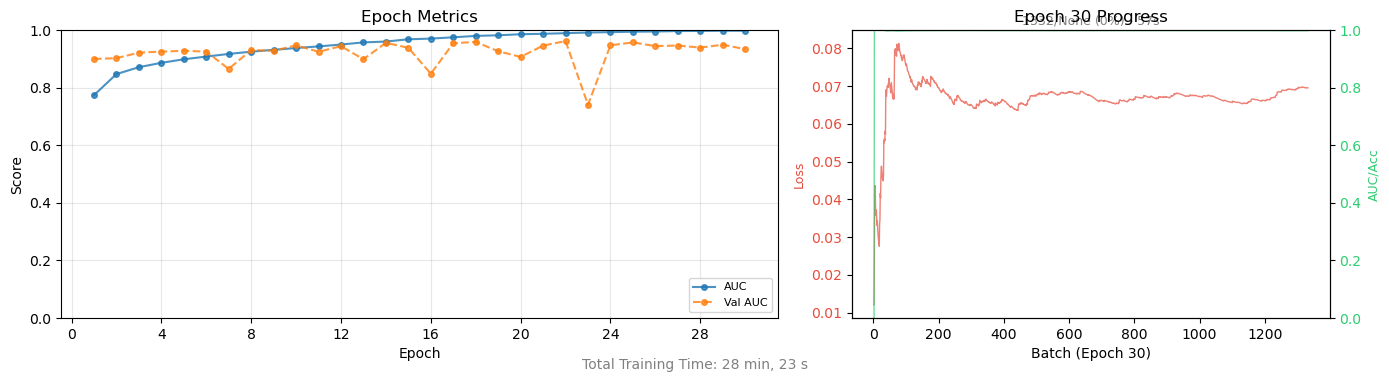

In [16]:
final_model = buildSequential(model_name='final_augmented')

train_ds = aX_train.to_tf_dataset(ay_train, batch_size=BATCH_SIZE, shuffle=True)
valid_ds = vX_valid.to_tf_dataset(vy_valid, batch_size=BATCH_SIZE, shuffle=False)

final_history = train_model(
    final_model, train_ds, valid_ds,
    epochs=80, patience=8, learning_rate=best_lr,
    live_plot=True
)

/home/etudie/PROJECTS/OCTCV/PART_2/../octcv/mdl_lib/__init__.py:679: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


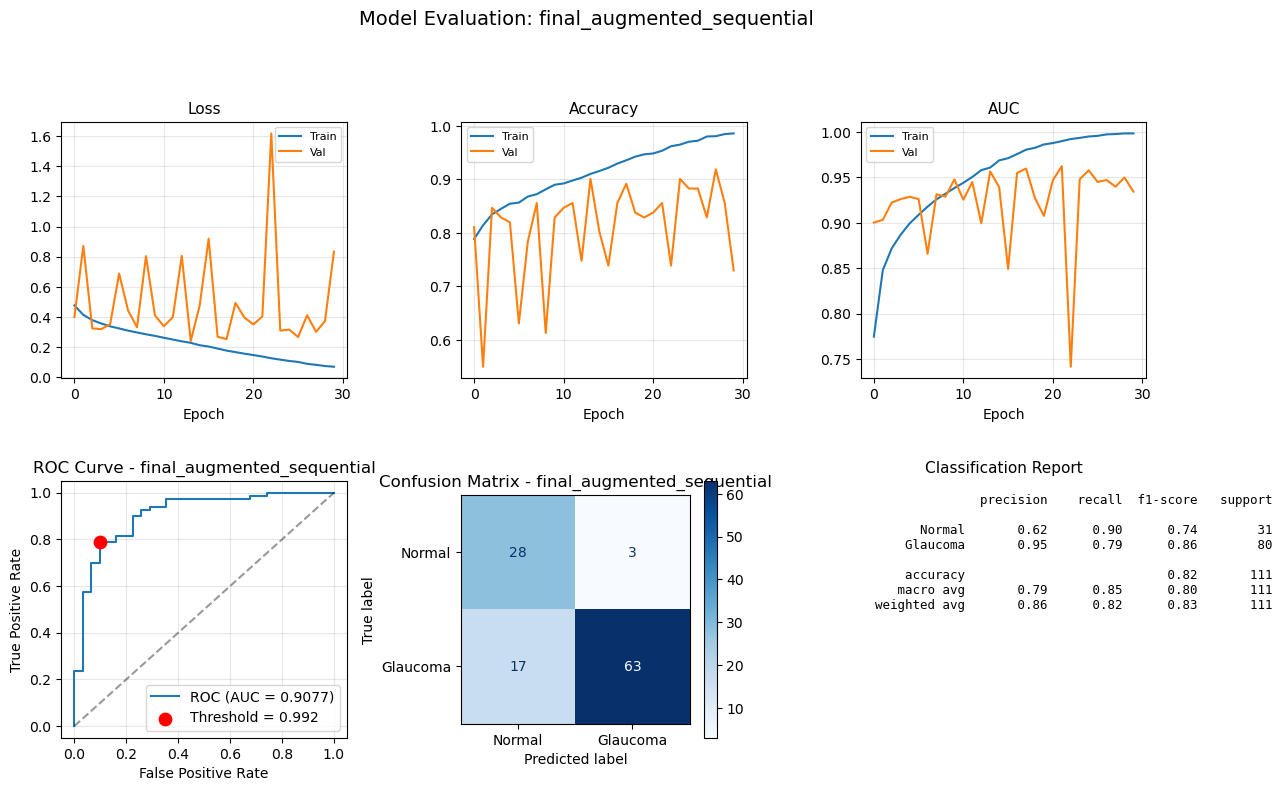


AUC: 0.9077 | Threshold: 0.9915


In [17]:
eval_ds = vX_eval.to_tf_dataset(vy_eval, batch_size=BATCH_SIZE, shuffle=False)
final_evaluator = ModelEvaluator(final_model, final_history, eval_ds)
final_evaluator.summary()

## Save Model

In [18]:
save_dir = os.path.join('..', 'p5_Modeling', 'models', 'augmented_final')
os.makedirs(save_dir, exist_ok=True)
final_model.save(os.path.join(save_dir, 'augmented_final.keras'))
print(f"Model saved to: {save_dir}")

Model saved to: ../p5_Modeling/models/augmented_final
